In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator
from Preprocess import preprocess_data

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = (
    preprocess_data(filtered_time, data_orig)
)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


In [3]:
# QRC Configuration
# num_layers: random rotation layers in the reservoir.
# shots: measurement shots per circuit.
# n_iterations: reservoir realizations to run; top_k are ensembled.
# top_k: number of best performing reservoirs to ensemble.
# correlation_threshold: Pearson correlation threshold for future if we have too many features. Select only the most relevant ones.
# random_seed: random seed for reproducibility.
QRC_CONFIG = {
    "num_layers": 3,
    "shots": 1024,
    "n_iterations": 10,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

# Classical regressor: "Ridge", "XGBoost", or "CatBoost"
CLASSICAL_MODEL_NAME = "XGBoost"

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)

QRC Config: {'num_layers': 3, 'shots': 1024, 'n_iterations': 10, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [4]:
def select_features_by_correlation(
    X_train, y_train, feature_cols, threshold
) -> tuple[list[int], list[str]]:
    """
    Select features by absolute Pearson correlation with target.

    Keeps features whose |correlation| >= threshold. With threshold <= 0,
    returns all features. Used to cap reservoir size when many features exist.

    Parameters
    ---
    X_train : ndarray of shape (n_samples, n_features)
        Training feature matrix.
    y_train : array-like of shape (n_samples,)
        Target values.
    feature_cols : list of str
        Feature column names.
    threshold : float
        Minimum |correlation| to keep; <= 0 returns all.

    Returns
    ---
    selected_idx : list of int
        Indices of selected features.
    selected_names : list of str
        Names of selected features.
    """
    if threshold <= 0.0:
        return list(range(len(feature_cols))), feature_cols

    selected_idx = []
    selected_names = []
    for i, col in enumerate(feature_cols):
        corr = np.abs(np.corrcoef(X_train[:, i], y_train)[0, 1])
        if corr >= threshold:
            selected_idx.append(i)
            selected_names.append(col)
    return selected_idx, selected_names


selected_idx, selected_features = select_features_by_correlation(
    X_train, y_train, feature_cols, QRC_CONFIG["correlation_threshold"]
)

X_train_sel = X_train[:, selected_idx]
X_val_sel = X_val[:, selected_idx]
X_test_sel = X_test[:, selected_idx]

n_qubits = len(selected_features)
n_states = 2**n_qubits

print(f"Selected features ({n_qubits}): {selected_features}")
print(f"Probability vector dimension: {n_states}")

Selected features (6): ['tide_deriv', 'form_fac', 'time_since', 'slip_size', 'high_t_evt', 'tide_height']
Probability vector dimension: 64


In [5]:
def scale_to_pi_range(X_train, X_val, X_test):
    """
    Scale features to [0, pi] for quantum encoding.

    Uses min-max normalization fit on X_train. Val/test use train min/max
    to avoid leakage. Values outside [0, 1] after scaling are clipped.
    Constant features yield 0.0.

    Parameters
    ---
    X_train : ndarray of shape (n_samples_train, n_features)
        Training feature set.
    X_val : ndarray of shape (n_samples_val, n_features)
        Validation feature set.
    X_test : ndarray of shape (n_samples_test, n_features)
        Test feature set.

    Returns
    ---
    X_train_scaled : ndarray
        Training set scaled to [0, pi].
    X_val_scaled : ndarray
        Validation set scaled (train min/max).
    X_test_scaled : ndarray
        Test set scaled (train min/max).
    """
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0  # avoid division by zero for constant features

    def transform(X): # scale the features to [0, pi]
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)
print(f"Quantum-scaled train range: [{X_train_q.min():.4f}, {X_train_q.max():.4f}]")

Quantum-scaled train range: [0.0000, 3.1416]


In [6]:
def generate_random_angles(num_layers, n_qubits, rng):
    """
    Generate random rotation angles for reservoir layers.

    Each layer has Rx, Rz, Ry per qubit. Angles are in [0, 2*pi] for Bloch rotations.

    Parameters
    ---
    num_layers : int
        Number of reservoir layers.
    n_qubits : int
        Number of qubits.
    rng : np.random.Generator
        Random number generator.

    Returns
    ---
    ndarray of shape (num_layers, n_qubits, 3)
        Angles for Rx, Rz, Ry per layer and qubit.
    """
    return rng.uniform(0, 2 * np.pi, size=(num_layers, n_qubits, 3))


def build_reservoir_circuit(data_sample, random_angles, num_layers, n_qubits):
    """
    Build a quantum reservoir circuit for one input sample.

    Structure:
      1. Encoding: Ry(data_sample[i]) on qubit i.
      2. Reservoir: For each layer, Rx/Rz/Ry per qubit, then CNOT chain.
      3. Measurement: All qubits in computational basis |00...0> to |11...1>.

    Parameters
    ---
    data_sample : array-like of shape (n_qubits,)
        Feature vector where each value is in [0, pi].
    random_angles : ndarray of shape (num_layers, n_qubits, 3)
        Rx, Rz, Ry angles per layer and qubit.
    num_layers : int
        Number of reservoir layers.
    n_qubits : int
        Number of qubits.

    Returns
    ---
    qc : QuantumCircuit
        Circuit ready for measurement.
    """
    qc = QuantumCircuit(n_qubits)

    # Encoding layer
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)

    qc.barrier()

    # Reservoir layers
    for layer in range(num_layers):
        for i in range(n_qubits):
            qc.rx(float(random_angles[layer, i, 0]), i)
            qc.rz(float(random_angles[layer, i, 1]), i)
            qc.ry(float(random_angles[layer, i, 2]), i)
        # CNOT chain for entanglement, including closing the loop
        qc.cx(n_qubits - 1, 0)
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        # Connect the last qubit to the first to form a loop
        qc.barrier()

    qc.measure_all()
    return qc


# print a sample circuit for inspection
sample_rng = np.random.default_rng(0)
sample_angles = generate_random_angles(QRC_CONFIG["num_layers"], n_qubits, sample_rng)
sample_qc = build_reservoir_circuit(
    X_train_q[0], sample_angles, QRC_CONFIG["num_layers"], n_qubits
)
print(sample_qc)

         ┌────────────┐  ░  ┌────────────┐ ┌────────────┐┌─────────────┐ ┌───┐»
   q_0: ─┤ Ry(1.6502) ├──░──┤ Rx(4.0021) ├─┤ Rz(1.6951) ├┤ Ry(0.25744) ├─┤ X ├»
        ┌┴────────────┴┐ ░ ┌┴────────────┤ ├────────────┤└┬───────────┬┘ └─┬─┘»
   q_1: ┤ Ry(0.029725) ├─░─┤ Rx(0.10385) ├─┤ Rz(5.1099) ├─┤ Ry(5.735) ├────┼──»
        └┬────────────┬┘ ░ └┬────────────┤ ├────────────┤ ├───────────┴┐   │  »
   q_2: ─┤ Ry(1.7372) ├──░──┤ Rx(3.8116) ├─┤ Rz(4.5836) ├─┤ Ry(3.4157) ├───┼──»
         ├────────────┤  ░  ├────────────┤ ├────────────┤┌┴────────────┴┐  │  »
   q_3: ─┤ Ry(2.0035) ├──░──┤ Rx(5.8752) ├─┤ Rz(5.1262) ├┤ Ry(0.017207) ├──┼──»
         └─┬───────┬──┘  ░  ├────────────┤┌┴────────────┤└┬────────────┬┘  │  »
   q_4: ───┤ Ry(0) ├─────░──┤ Rx(5.3872) ├┤ Rz(0.21102) ├─┤ Ry(4.5846) ├───┼──»
         ┌─┴───────┴──┐  ░  ├────────────┤└┬────────────┤ ├────────────┤   │  »
   q_5: ─┤ Ry(2.1679) ├──░──┤ Rx(1.1037) ├─┤ Rz(5.4235) ├─┤ Ry(3.4021) ├───■──»
         └────────────┘  ░  └───────────

In [7]:
def run_quantum_reservoir(
    X_data, random_angles, num_layers, n_qubits, shots, batch_size=512
):
    """
    Execute quantum reservoir circuits and return measurement probabilities.

    Runs circuits in batches on AerSimulator. Each row of the output is the
    empirical probability distribution over 2^n_qubits basis states.

    Parameters
    ---
    X_data : ndarray of shape (m, n_qubits)
        Quantum-scaled feature matrix.
    random_angles : ndarray of shape (num_layers, n_qubits, 3)
        Reservoir rotation angles.
    num_layers : int
        Reservoir depth.
    n_qubits : int
        Number of qubits.
    shots : int
        Measurement shots per circuit.
    batch_size : int, optional
        Circuits per simulator batch (default 512).

    Returns
    ---
    prob_matrix : ndarray of shape (m, 2**n_qubits)
        Row-normalized probability vectors.
    """
    m = X_data.shape[0]  # number of rows in the feature matrix
    n_states = 2**n_qubits
    prob_matrix = np.zeros((m, n_states))

    simulator = AerSimulator()

    # Build all circuits
    circuits = []
    for i in range(m):
        qc = build_reservoir_circuit(
            X_data[i], random_angles, num_layers, n_qubits
        )  # build the circuit for the i-th row of the feature matrix
        circuits.append(qc)

    # Execute in batches
    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch = circuits[start:end]
        result = simulator.run(batch, shots=shots).result()

        counts_list = result.get_counts()
        # get_counts() returns a dict for single circuit, list for multiple
        if isinstance(counts_list, dict):
            counts_list = [counts_list]

        for j, counts in enumerate(counts_list):
            for bitstring, count in counts.items():
                idx = int(bitstring.replace(" ", ""), 2)
                prob_matrix[start + j, idx] = count / shots

    return prob_matrix


# run reservoir on 3 samples and verify probability row sums to verify the circuit is working
test_angles = generate_random_angles(
    QRC_CONFIG["num_layers"], n_qubits, np.random.default_rng(0)
)
test_prob = run_quantum_reservoir(
    X_train_q[:3], test_angles, QRC_CONFIG["num_layers"], n_qubits, QRC_CONFIG["shots"]
)
print(f"Probability matrix shape: {test_prob.shape}")
print(f"Row sums (should be ~1.0): {test_prob.sum(axis=1)}")

Probability matrix shape: (3, 64)
Row sums (should be ~1.0): [1. 1. 1.]


In [8]:
def get_model_registry():
    """
    Return registry of classical regressors for QRC readout.

    Each entry has:
      - optuna_fn: maps trial -> hyperparams dict
      - fixed_params: fixed model params
      - build_fn: params -> model instance
      - fit_fn: (model, P_train, y_train, P_val, y_val) -> None
      - shap_explainer: "linear", "tree", or "kernel"

    Returns
    ---
    dict
        Model name -> config dict.
    """
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.01, 0.1, log=True
                ),
                "max_depth": trial.suggest_int("max_depth", 2, 5),
                "subsample": trial.suggest_float("subsample", 0.6, 0.9),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
            },
            "fixed_params": {
                "objective": "reg:squarederror",
                "n_estimators": 1000,
                "random_state": 42,
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=[(Xv, yv)], verbose=False
            ),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.01, 0.1, log=True
                ),
                "depth": trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations": 100,
                "loss_function": "RMSE",
                "eval_metric": "RMSE",
                "random_seed": 42,
                "verbose": False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=(Xv, yv), use_best_model=True
            ),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")

Available models: ['Ridge', 'XGBoost', 'CatBoost']
Using: XGBoost


In [ ]:
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q,
    X_val_q,
    X_test_q,
    y_train,
    y_val,
    y_test,
    n_qubits,
    config,
    model_name,
    registry,
):
    """
    Run one QRC iteration: reservoir + Optuna tuning + train + evaluate.

    Steps: (1) generate seeded random angles, (2) run reservoir on all splits,
    (3) Optuna hyperparameter search, (4) train best model, (5) return metrics.

    Parameters
    ---
    iteration_idx : int
        Iteration index; used for RNG seeding.
    X_train_q, X_val_q, X_test_q : ndarray
        Quantum-scaled feature matrices.
    y_train, y_val, y_test : array-like
        Target vectors.
    n_qubits : int
        Number of qubits.
    config : dict
        QRC config (num_layers, shots, random_seed).
    model_name : str
        Key in registry for classical regressor.
    registry : dict
        Model registry from get_model_registry().

    Returns
    ---
    dict
        iteration, val_r2, val_rmse, test_rmse, test_mae, test_pred,
        best_params, model, P_train, P_val, P_test.
    """
    num_layers = config["num_layers"]
    shots = config["shots"]
    seed = config["random_seed"] + iteration_idx

    rng = np.random.default_rng(seed)
    random_angles = generate_random_angles(num_layers, n_qubits, rng) # generate random angles for the reservoir

    # Run quantum reservoir on all splits
    P_train = run_quantum_reservoir(X_train_q, random_angles, num_layers, n_qubits, shots)
    P_val = run_quantum_reservoir(X_val_q, random_angles, num_layers, n_qubits, shots)
    P_test = run_quantum_reservoir(X_test_q, random_angles, num_layers, n_qubits, shots)

    # Get information about the model from the registry for hyperparameter tuning
    entry = registry[model_name]

    def objective(trial): # objective function for hyperparameter tuning
        tuned = entry["optuna_fn"](trial) # get the tuned parameters
        params = {**entry["fixed_params"], **tuned} # combine the fixed parameters with the tuned parameters
        model = entry["build_fn"](params) # build the model
        entry["fit_fn"](model, P_train, y_train, P_val, y_val) # train the model
        preds = model.predict(P_val) # predict the validation set
        return root_mean_squared_error(y_val, preds) # return the RMSE of the validation set

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30) # optimize the model

    # Train final model with best params
    best_tuned = entry["optuna_fn"](study.best_trial) # get the best tuned parameters
    best_params = {**entry["fixed_params"], **best_tuned} # combine the fixed parameters with the best tuned parameters
    model = entry["build_fn"](best_params) # build the model
    entry["fit_fn"](model, P_train, y_train, P_val, y_val) # train the model

    # Evaluate
    val_pred = model.predict(P_val)
    test_pred = model.predict(P_test)

    val_r2 = r2_score(y_val, val_pred)
    val_rmse = root_mean_squared_error(y_val, val_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    return {
        "iteration": iteration_idx,
        "val_r2": val_r2,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_pred": test_pred,
        "best_params": best_params,
        "model": model,
        "P_train": P_train,
        "P_val": P_val,
        "P_test": P_test,
    }

# test running a single iteration of the QRC pipeline
res = run_single_qrc_iteration(

In [10]:
def run_qrc_pipeline(
    X_train_q,
    X_val_q,
    X_test_q,
    y_train,
    y_val,
    y_test,
    n_qubits,
    config,
    model_name,
    registry,
):
    """
    Run full QRC pipeline: n_iterations, ensemble top-k by validation R2.

    Parameters
    ---
    X_train_q, X_val_q, X_test_q : ndarray
        Quantum-scaled feature matrices.
    y_train, y_val, y_test : array-like
        Target vectors.
    n_qubits : int
        Number of qubits.
    config : dict
        QRC config
    model_name : str
        Classical regressor name.
    registry : dict
        Model registry.

    Returns
    ---
    results : list of dict
        Per-iteration results.
    ensemble_pred : ndarray
        Averaged test predictions from top-k iterations.
    top_indices : list of int
        Indices of iterations used in ensemble.
    """
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q,
            X_val_q,
            X_test_q,
            y_train,
            y_val,
            y_test,
            n_qubits,
            config,
            model_name,
            registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | Test RMSE: {res['test_rmse']:.2f} | Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    # Select top-k by validation R-squared
    top_k = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_r2"], reverse=True)
    top_results = sorted_results[:top_k]
    top_indices = [r["iteration"] for r in top_results]

    print(f"\nTop-{top_k} iterations (by val R²): {[i + 1 for i in top_indices]}")

    # Ensemble: average test predictions of top-k
    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    ensemble_rmse = root_mean_squared_error(y_test, ensemble_pred)
    ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
    ensemble_r2 = r2_score(y_test, ensemble_pred)

    print(f"\nEnsemble Test RMSE: {ensemble_rmse:.2f}")
    print(f"Ensemble Test MAE:  {ensemble_mae:.2f}")
    print(f"Ensemble Test R²:   {ensemble_r2:.4f}")

    return results, ensemble_pred, top_indices


# Execute full QRC pipeline (may take several minutes)
all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q,
    X_val_q,
    X_test_q,
    y_train,
    y_val,
    y_test,
    n_qubits,
    QRC_CONFIG,
    CLASSICAL_MODEL_NAME,
    registry,
)


Iteration 1/10:
	Val R2: 0.1497 | Val RMSE: 18646.00 | Test RMSE: 18809.83 | Test MAE: 15527.05

Iteration 2/10:
	Val R2: 0.1344 | Val RMSE: 18812.13 | Test RMSE: 18539.94 | Test MAE: 15341.24

Iteration 3/10:
	Val R2: 0.1419 | Val RMSE: 18731.29 | Test RMSE: 18718.30 | Test MAE: 15524.65

Iteration 4/10:
	Val R2: 0.1437 | Val RMSE: 18711.36 | Test RMSE: 18651.50 | Test MAE: 15477.14

Iteration 5/10:
	Val R2: 0.1332 | Val RMSE: 18825.48 | Test RMSE: 19070.03 | Test MAE: 15556.78

Iteration 6/10:
	Val R2: 0.1400 | Val RMSE: 18751.84 | Test RMSE: 18678.38 | Test MAE: 15423.80

Iteration 7/10:
	Val R2: 0.1517 | Val RMSE: 18624.13 | Test RMSE: 18583.80 | Test MAE: 15285.61

Iteration 8/10:
	Val R2: 0.1631 | Val RMSE: 18497.75 | Test RMSE: 18922.94 | Test MAE: 15450.76

Iteration 9/10:
	Val R2: 0.1522 | Val RMSE: 18617.89 | Test RMSE: 18943.07 | Test MAE: 15675.86

Iteration 10/10:
	Val R2: 0.1668 | Val RMSE: 18457.63 | Test RMSE: 19060.58 | Test MAE: 15487.23

Top-3 iterations (by val R²)

In [ ]:
# Build results summary table: per-iteration metrics and ensemble.
# Asterisk marks top-k iterations; double-asterisk marks ensemble.
rows = []
for r in all_results:
    rows.append(
        {
            "Iteration": r["iteration"] + 1,
            "Val R2": f"{r['val_r2']:.4f}",
            "Val RMSE": f"{r['val_rmse']:.2f}",
            "Test RMSE": f"{r['test_rmse']:.2f}",
            "Test MAE": f"{r['test_mae']:.2f}",
            "Top-k": "*" if r["iteration"] in top_indices else "",
        }
    )

ensemble_rmse = root_mean_squared_error(y_test, ensemble_pred)
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_r2 = r2_score(y_test, ensemble_pred)
rows.append(
    {
        "Iteration": "Ensemble",
        "Val R2": "-",
        "Val RMSE": "-",
        "Test RMSE": f"{ensemble_rmse:.2f}",
        "Test MAE": f"{ensemble_mae:.2f}",
        "Top-k": "**",
    }
)

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

Iteration Val R² Val RMSE Test RMSE Test MAE Top-k
        1 0.1497 18646.00  18809.83 15527.05      
        2 0.1344 18812.13  18539.94 15341.24      
        3 0.1419 18731.29  18718.30 15524.65      
        4 0.1437 18711.36  18651.50 15477.14      
        5 0.1332 18825.48  19070.03 15556.78      
        6 0.1400 18751.84  18678.38 15423.80      
        7 0.1517 18624.13  18583.80 15285.61      
        8 0.1631 18497.75  18922.94 15450.76     *
        9 0.1522 18617.89  18943.07 15675.86     *
       10 0.1668 18457.63  19060.58 15487.23     *
 Ensemble      -        -  18655.89 15425.83    **


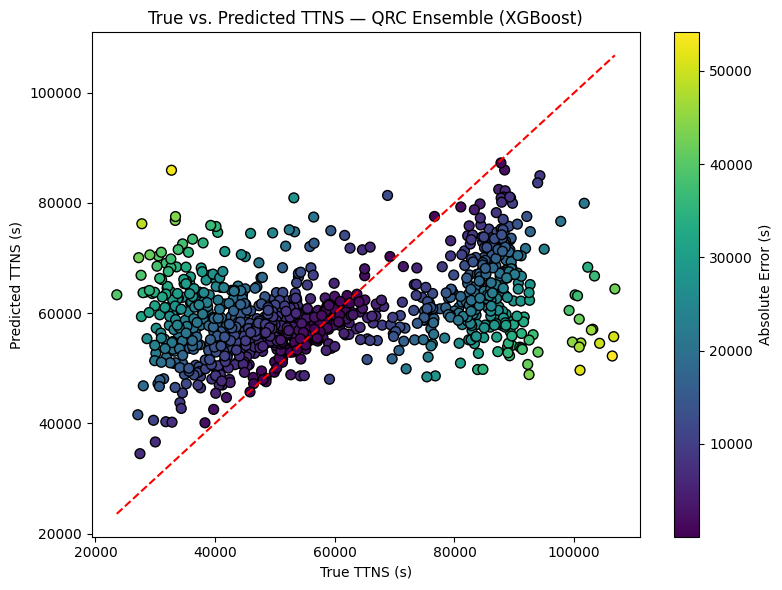

In [17]:
# Scatter: true vs predicted TTNS. Color = absolute error (seconds).
y_test_arr = np.asarray(y_test)
absolute_error = np.abs(ensemble_pred - y_test_arr)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_test_arr,
    ensemble_pred,
    c=absolute_error,
    cmap="viridis",
    s=50,
    edgecolors="black",
)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_arr), max(y_test_arr)], [min(y_test_arr), max(y_test_arr)], "r--")
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title(f"True vs. Predicted TTNS — QRC Ensemble ({CLASSICAL_MODEL_NAME})")
plt.tight_layout()
plt.show()

 96%|=================== | 939/980 [00:14<00:00]       

Top-20 most important quantum states (Iteration 10):
110010    927.095325
111100    888.384421
111110    878.094856
011101    843.459452
010011    775.546661
111001    749.560253
000001    700.233890
011011    691.394826
011010    678.562955
001100    676.218410
011111    654.235190
110000    604.615279
001010    594.717459
111101    584.997529
001110    580.775531
001111    559.925147
100111    541.770507
000100    534.474355
011000    529.516143
011110    466.409193
dtype: float64


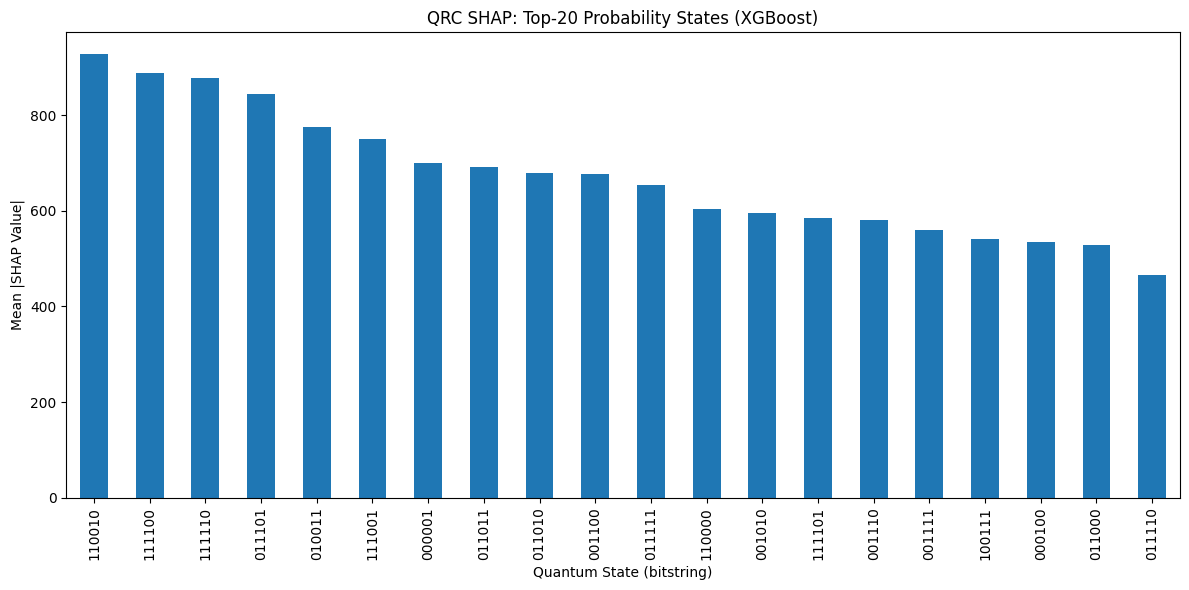

In [13]:
# SHAP: feature importance of quantum states for best iteration.
# Explainer type depends on model (linear/tree/kernel).
best_result = sorted(all_results, key=lambda r: r["val_r2"], reverse=True)[0]
best_model = best_result["model"]
P_test_best = best_result["P_test"]

# Feature names are bitstrings
bitstring_names = [format(i, f"0{n_qubits}b") for i in range(n_states)]
P_test_df = pd.DataFrame(P_test_best, columns=bitstring_names)

# Select explainer based on model type
explainer_type = registry[CLASSICAL_MODEL_NAME]["shap_explainer"]
if explainer_type == "linear":
    explainer = shap.LinearExplainer(
        best_model, P_test_df, feature_perturbation="interventional"
    )
elif explainer_type == "tree":
    explainer = shap.TreeExplainer(
        best_model, P_test_df, feature_perturbation="interventional"
    )
else:
    explainer = shap.KernelExplainer(best_model.predict, P_test_df.iloc[:50])

shap_values = explainer.shap_values(P_test_df)

# Top-20 probability states by mean |SHAP|
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=bitstring_names
).sort_values(ascending=False)
print(
    f"Top-20 most important quantum states (Iteration {best_result['iteration'] + 1}):"
)
print(mean_shap.head(20))

plt.figure(figsize=(12, 6))
mean_shap.head(20).plot(kind="bar")
plt.title(f"QRC SHAP: Top-20 Probability States ({CLASSICAL_MODEL_NAME})")
plt.ylabel("Mean |SHAP Value|")
plt.xlabel("Quantum State (bitstring)")
plt.tight_layout()
plt.show()

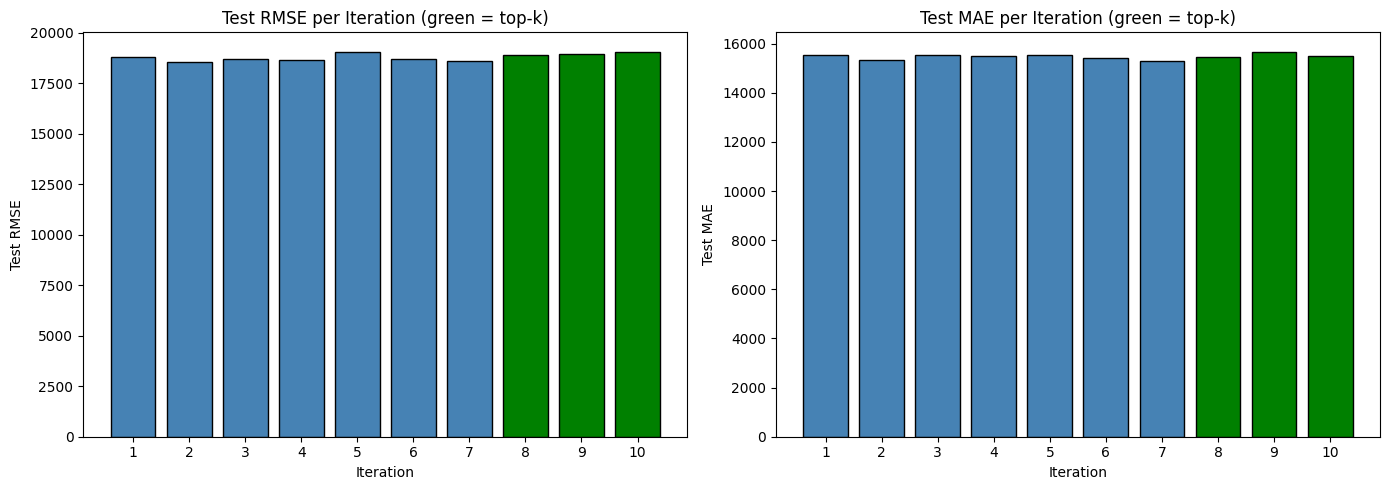

In [16]:
# Bar charts: test RMSE and test MAE per iteration. Green = top-k ensemble members.
iterations = [r["iteration"] + 1 for r in all_results]
test_rmses = [r["test_rmse"] for r in all_results]
test_maes = [r.get("test_mae") if "test_mae" in r else None for r in all_results]
colors = [
    "green" if r["iteration"] in top_indices else "steelblue" for r in all_results
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(iterations, test_rmses, color=colors, edgecolor="black")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("Test RMSE per Iteration (green = top-k)")
axes[0].set_xticks(iterations)

axes[1].bar(iterations, test_maes, color=colors, edgecolor="black")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Test MAE")
axes[1].set_title("Test MAE per Iteration (green = top-k)")
axes[1].set_xticks(iterations)

plt.tight_layout()
plt.show()

  0%|          | 0/75 [00:00<?, ?it/s]

SHAP importance (mean |SHAP|) — original features:
tide_height    3939.015085
high_t_evt     2841.042764
time_since     2493.108030
tide_deriv     1890.119270
slip_size      1606.565144
form_fac        848.057879
dtype: float64


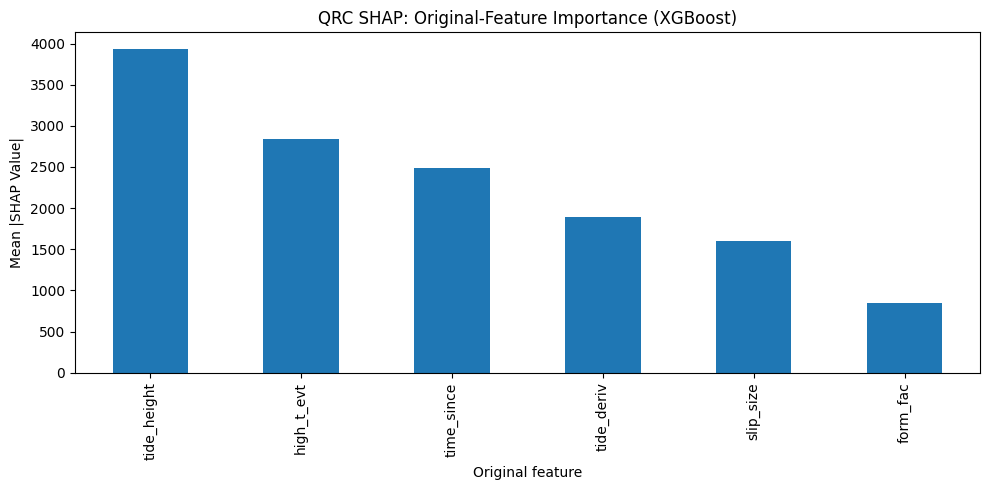

In [20]:
# SHAP for original features: wrapper runs full pipeline (scale -> reservoir -> model).
# KernelSHAP is model-agnostic each eval runs the quantum reservoir (expensive but interpretable).
def predict_from_original_features(
    X_orig,
    random_angles,
    model,
    train_min,
    train_max,
    num_layers,
    n_qubits,
    shots,
):
    """
    Predict from original (selected) features by running scale -> reservoir -> model.
    X_orig: (n_samples, n_features) in same scale as X_train_sel (StandardScaler output).
    """
    denom = train_max - train_min
    denom = np.where(denom == 0, 1.0, denom)
    X_scaled = np.clip((X_orig - train_min) / denom, 0.0, 1.0) * np.pi
    P = run_quantum_reservoir(X_scaled, random_angles, num_layers, n_qubits, shots)
    return model.predict(P)


# Recreate reservoir angles for best iteration (deterministic from seed)
best_result = sorted(all_results, key=lambda r: r["val_r2"], reverse=True)[0]
seed = QRC_CONFIG["random_seed"] + best_result["iteration"]
rng = np.random.default_rng(seed)
best_angles = generate_random_angles(QRC_CONFIG["num_layers"], n_qubits, rng)
train_min = X_train_sel.min(axis=0)
train_max = X_train_sel.max(axis=0)

# KernelSHAP on original features (small background/nsamples for speed — each eval runs reservoir)
X_background = X_test_sel[:25]
X_explain = X_test_sel[:75]

def predict_wrapper(X_orig):
    return predict_from_original_features(
        X_orig, best_angles, best_result["model"],
        train_min, train_max, QRC_CONFIG["num_layers"], n_qubits, QRC_CONFIG["shots"],
    )

explainer = shap.KernelExplainer(predict_wrapper, X_background)
shap_orig = explainer.shap_values(X_explain, nsamples=150)

# Mean |SHAP| per original feature
mean_shap_orig = pd.Series(
    np.abs(shap_orig).mean(axis=0), index=selected_features
).sort_values(ascending=False)
print("SHAP importance (mean |SHAP|) — original features:")
print(mean_shap_orig)

plt.figure(figsize=(10, 5))
mean_shap_orig.plot(kind="bar")
plt.title(f"QRC SHAP: Original-Feature Importance ({CLASSICAL_MODEL_NAME})")
plt.ylabel("Mean |SHAP Value|")
plt.xlabel("Original feature")
plt.tight_layout()
plt.show()